In [3]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset from Hugging Face
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
# Convert the date column to a proper datetime format so we can analyze trend over time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert the text strings in the skills column into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [4]:

# Outlier Handling for Salary (Creating a safe, filtered dataframe for salary analysis)
# We calculate the Interquartile Range (IQR) to drop extreme salary outliers
Q1 = df["salary_year_avg"].quantile(0.25)
Q3 = df["salary_year_avg"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_salary_cleaned = df[
    (df["salary_year_avg"] >= lower_bound) & (df["salary_year_avg"] <= upper_bound)
]

print("Data Cleaning Complete!")
print(f"Original dataset rows: {len(df)}")
print(
    f"Cleaned salary dataset rows: {len(df_salary_cleaned)} (Excludes outliers and nulls)"
)

Data Cleaning Complete!
Original dataset rows: 785741
Cleaned salary dataset rows: 21587 (Excludes outliers and nulls)


In [5]:
# Filtering for Data Analyst roles in the US job market.
df_DA_US = df[
    (df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")
].copy()

# We must also drop any rows with missing salary data so that the calculations are perfectly accurate.
df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"])

In [6]:
# Explode the skills list so we can calculate the exact metrics for each individual tool.
df_DA_US_exploded = df_DA_US.explode("job_skills")

df_DA_US_exploded[["salary_year_avg", "job_skills"]].head(5)   # to check

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [7]:
# Calculate the two most important metrics for every skill:  
# 1. How common it is (Count of job postings)
# 2. How much it pays (Median Salary)
df_DA_skills = (
    df_DA_US_exploded.groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values(by="count", ascending=False)
)

df_DA_skills = df_DA_skills.rename(
    columns={"count": "skill_count", "median": "median_salary"}
)

# Converting the raw count into a percentage of total jobs. 
# This tells us exactly how likely a job seeker is to see this skill requested in a job description.
DA_job_count = len(df_DA_US)
df_DA_skills["skill_percent"] = df_DA_skills["skill_count"] / DA_job_count * 100


# Filtering out highly niche skills and only look at tools that appear in at least 5% of all job postings.
skill_min_percent = 5
df_optimal = df_DA_skills[df_DA_skills["skill_percent"] > skill_min_percent]

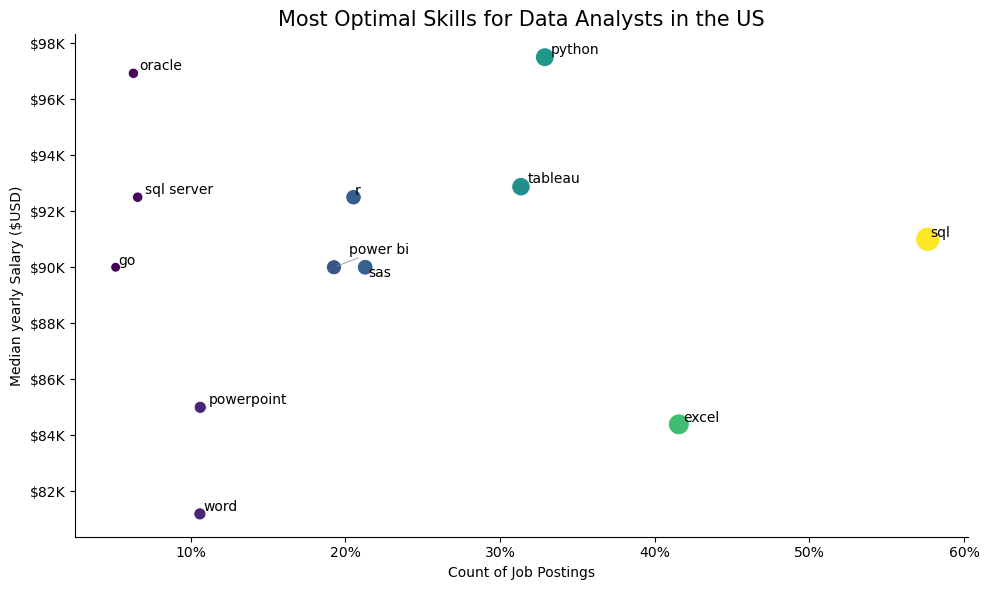

In [10]:
# Generate a scatter plot to visualize the "Sweet Spot" for Data Analysts.
# Skills that are on the top-right quadrant represent the highest Return on Investment (High Demand + High Salary).

# adjusting the text on scatter plot to make it look clean
from adjustText import adjust_text # 
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_optimal,
    x="skill_percent",
    y="median_salary",
    hue="skill_percent",
    palette="viridis",
    size="skill_percent",
    sizes=(50, 300),
    legend=False,
    ax=ax,
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}%'))

# Use adjust_text to automatically arrange our skill labels so they don't overlap and become unreadable.
texts = []
for i, txt in enumerate(df_optimal.index):
    texts.append(
        plt.text(
            df_optimal["skill_percent"].iloc[i],
            df_optimal["median_salary"].iloc[i],
            txt,
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.title("Most Optimal Skills for Data Analysts in the US", fontsize=15)
plt.xlabel("Count of Job Postings")
plt.ylabel("Median yearly Salary ($USD)")
sns.despine()

# Adjust layout
plt.tight_layout()
plt.show()